[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\zhuma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zhuma\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\zhuma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\zhuma\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



Sentiment Summary:
Sentiment Label
Positive    964
Negative     91
Neutral       1
Name: count, dtype: int64

Summary Report:
Total Reviews: 1056
Average Polarity Score: 0.23
Average Compound Score (VADER): 0.77

Identified Topics:
Topic 1: film, dune, paul, character, arrakis
Topic 2: movie, like, book, character, paul
Topic 3: movie, film, dune, best, denis

Top 3 Positive Reviews:
                                        Review Content  Compound
200  Following the events of the first Dune film, P...    0.9999
380  Rating: 9.4\nOverall, a technical masterpiece ...    0.9999
517  LONG LIVE THE FIGHTERS!This film being a maste...    0.9998

Top 3 Negative Reviews:
                                         Review Content  Compound
635   My perspective so you understand my review bet...   -0.9958
890   Dune is a very good movie, and that makes its ...   -0.9911
1053  The goliath that is the overhype for this film...   -0.9889

Neutral Review(s):
                                        Rev

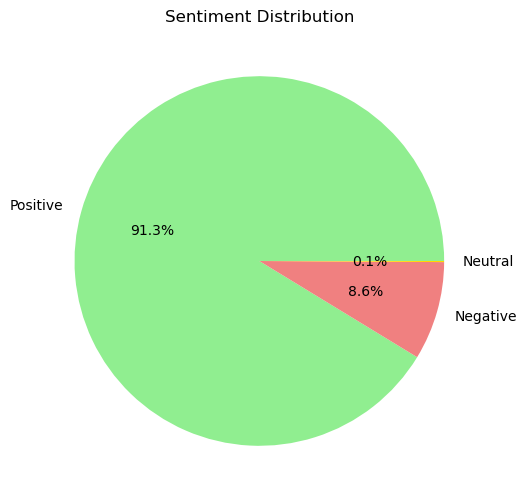

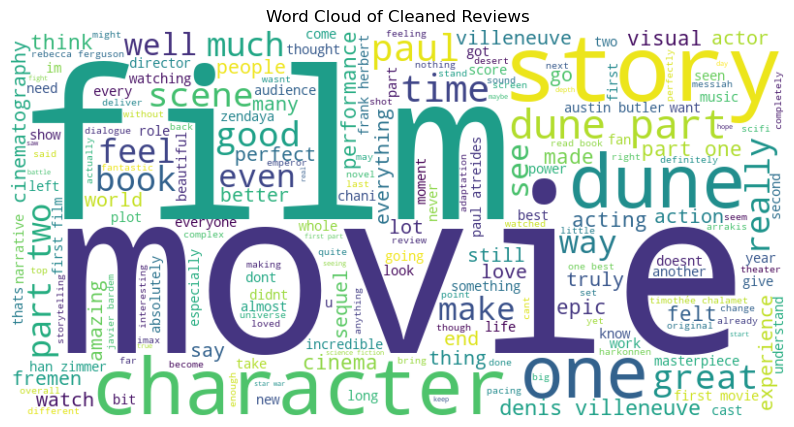

C:\Users\zhuma\AppData\Local\Temp\ipykernel_10300\962735143.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['Sentiment Label'], order=['Positive', 'Negative', 'Neutral'], palette='viridis')


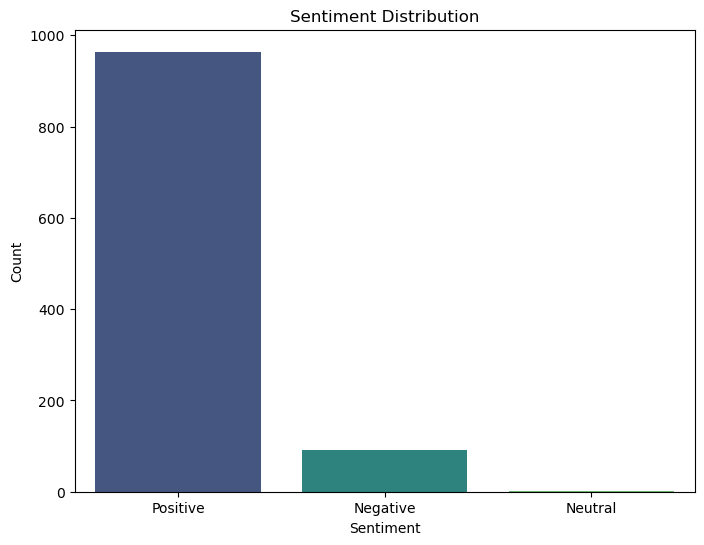

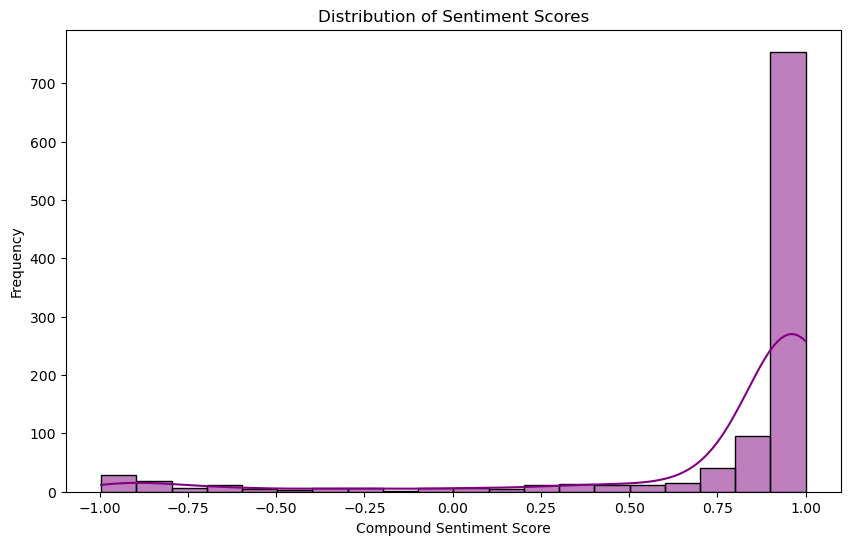

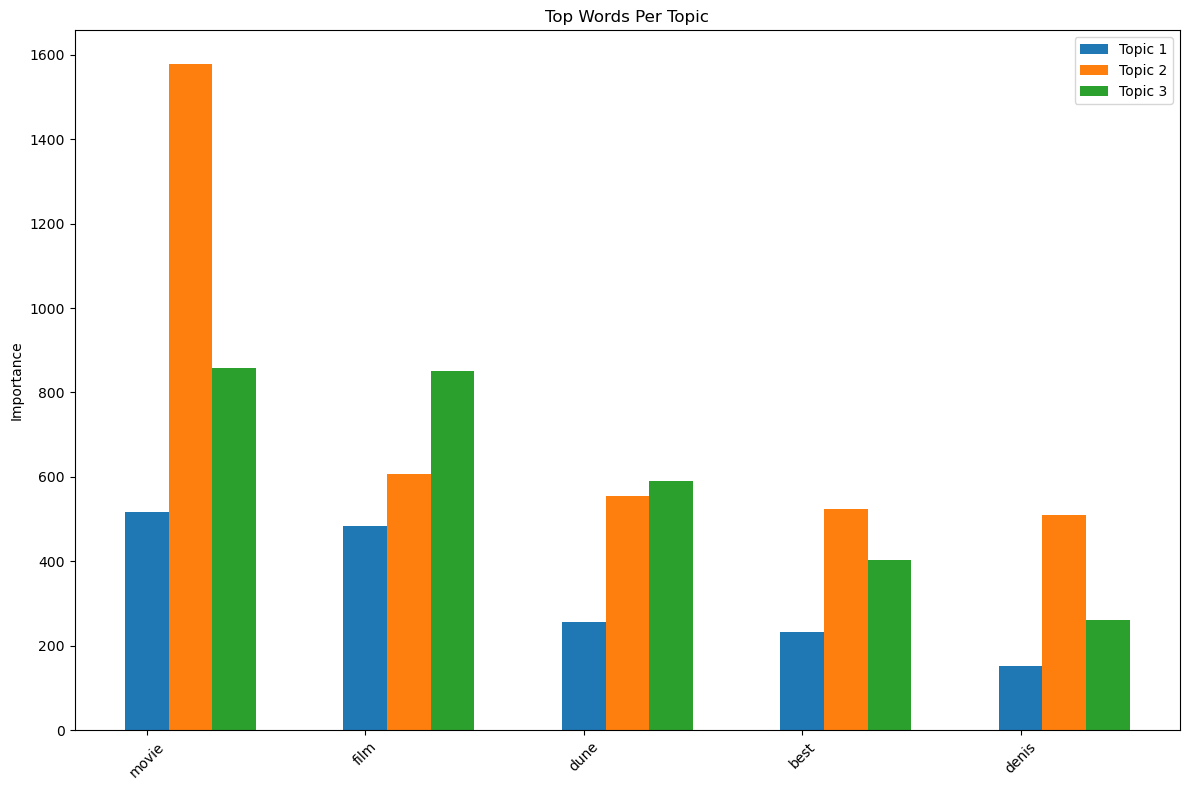

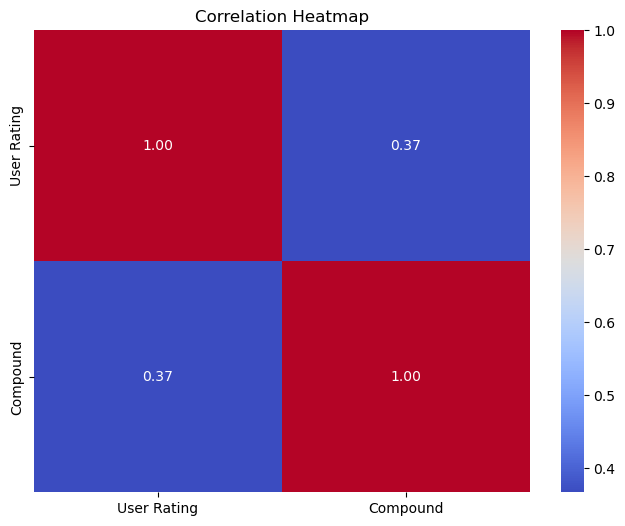

C:\Users\zhuma\AppData\Local\Temp\ipykernel_10300\962735143.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='User Rating', y='Compound', data=data, palette='coolwarm')


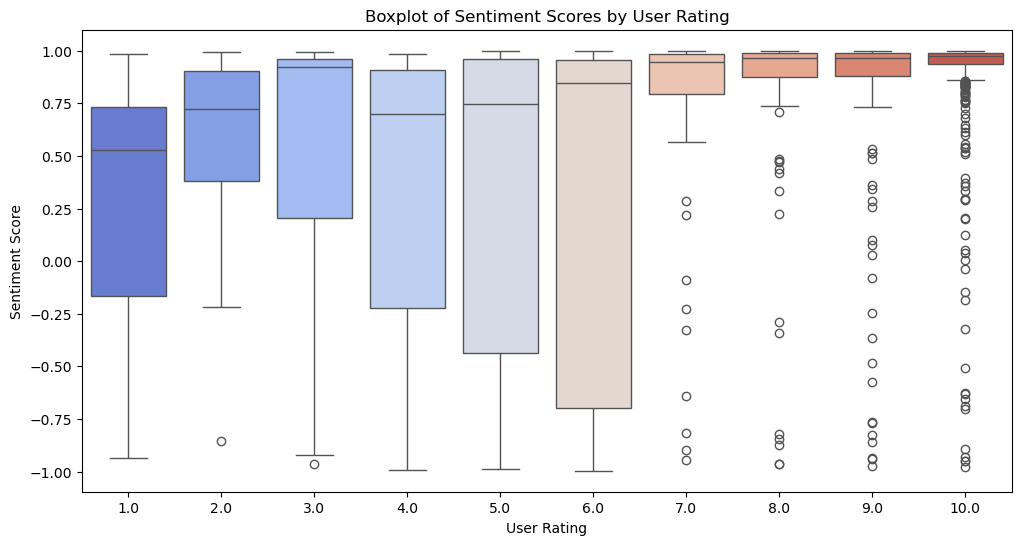

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import nltk
import re
import string
import numpy as np

#Ensure required NLTK data is downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('vader_lexicon')

#Load data
file_path = 'dune_2_reviews.csv'  # Replace with your file path
data = pd.read_csv(file_path)

#Drop rows with missing 'User Rating'
data.dropna(subset=['User Rating'], inplace=True)

#Text Preprocessing Function
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    tokens = word_tokenize(text)  # Tokenize
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatize
    return ' '.join(tokens)

#Apply preprocessing to each text entry
data['Cleaned Review'] = data['Review Content'].apply(preprocess_text)

#Sentiment Analysis using TextBlob
def analyze_sentiment_textblob(text):
    analysis = TextBlob(text)
    return analysis.polarity, analysis.subjectivity

data['Polarity'], data['Subjectivity'] = zip(*data['Cleaned Review'].apply(analyze_sentiment_textblob))

#Sentiment Analysis using VADER
analyzer = SentimentIntensityAnalyzer()
data['VADER Scores'] = data['Review Content'].apply(lambda x: analyzer.polarity_scores(x))
data['Compound'] = data['VADER Scores'].apply(lambda x: x['compound'])

#Classify sentiments
data['Sentiment Label'] = data['Compound'].apply(lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral')

#Summary of Sentiment
sentiment_counts = data['Sentiment Label'].value_counts()
print("\nSentiment Summary:")
print(sentiment_counts)

#LDA Topic Modeling
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
review_matrix = vectorizer.fit_transform(data['Cleaned Review'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(review_matrix)

words = vectorizer.get_feature_names_out()

#Extract top 5 words for each topic
topics = {}
for i, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-5:][::-1]  # Get top 5 words for each topic
    topics[f"Topic {i+1}"] = [words[idx] for idx in top_words_idx]

#Print Summary Metrics
print("\nSummary Report:")
print(f"Total Reviews: {len(data)}")
print(f"Average Polarity Score: {data['Polarity'].mean():.2f}")
print(f"Average Compound Score (VADER): {data['Compound'].mean():.2f}")
print("\nIdentified Topics:")
for topic, words in topics.items():
    print(f"{topic}: {', '.join(words)}")

# Printing Top Reviews
print("\nTop 3 Positive Reviews:")
print(data[data['Sentiment Label'] == 'Positive']
      .nlargest(3, 'Compound')[['Review Content', 'Compound']])

print("\nTop 3 Negative Reviews:")
print(data[data['Sentiment Label'] == 'Negative']
      .nsmallest(3, 'Compound')[['Review Content', 'Compound']])

print("\nNeutral Review(s):")
neutral_reviews = data[data['Sentiment Label'] == 'Neutral']
if neutral_reviews.empty:
    print("No neutral reviews found.")
else:
    print(neutral_reviews[['Review Content', 'Compound']])

#Visualization
#1. Pie Chart for Sentiment Distribution
plt.figure(figsize=(8, 6))
sentiment_counts.plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'lightcoral', 'gold'])
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()

#2. Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(data['Cleaned Review']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Reviews')
plt.show()

#3. Bar Chart for Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=data['Sentiment Label'], order=['Positive', 'Negative', 'Neutral'], palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

#4. Histogram of Sentiment Scores
plt.figure(figsize=(10, 6))
sns.histplot(data['Compound'], bins=20, kde=True, color='purple')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()

#5. Top Words Per Topic (Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(12, 8))
for i, topic in enumerate(topics.keys()):
    top_words = topics[topic]
    ax.bar(np.arange(len(top_words)) + i * 0.2, lda.components_[i][lda.components_[i].argsort()[-5:]][::-1], 
           width=0.2, label=topic)
ax.set_xticks(np.arange(len(top_words)))
ax.set_xticklabels(top_words, rotation=45)
ax.set_title('Top Words Per Topic')
ax.set_ylabel('Importance')
ax.legend()
plt.tight_layout()
plt.show()

#6. Correlation Heatmap (if User Rating is numerical)
if pd.api.types.is_numeric_dtype(data['User Rating']):
    plt.figure(figsize=(8, 6))
    correlation_matrix = data[['User Rating', 'Compound']].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

#7. Boxplot of Sentiment Scores by User Rating
if pd.api.types.is_numeric_dtype(data['User Rating']):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='User Rating', y='Compound', data=data, palette='coolwarm')
    plt.title('Boxplot of Sentiment Scores by User Rating')
    plt.xlabel('User Rating')
    plt.ylabel('Sentiment Score')
    plt.show()
